In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
np.random.seed(42)

def make_category(name, n, price_lo, price_hi, rating_mu, review_mu):
    ratings_raw = np.clip(np.random.normal(rating_mu, 0.4, n), 1.0, 5.0).round(1)
    reviews_raw = np.abs(np.random.normal(review_mu, review_mu * 0.3, n)).astype(int)
    prices_raw  = np.random.uniform(price_lo, price_hi, n).round(2)
    return pd.DataFrame({
        'Product Name':  [f'{name} Product {i+1}' for i in range(n)],
        'Category':      [name] * n,
        'Price':         [f'\u20b9{p:,.0f}' for p in prices_raw],   
        'Rating':        ratings_raw.astype(str),
        'Reviews_Text':  [f'{r} Ratings' for r in reviews_raw],
        'No_of_Reviews': reviews_raw,
    })

df = pd.concat([
    make_category('Tyres',  120,  800, 8000, 3.8, 450),   
    make_category('Brake',  100,  200, 2500, 4.1, 320),   
    make_category('Clutch',  90,  500, 5000, 3.6, 280),   
    make_category('Oil',    110,  100, 1500, 4.3, 600),   
], ignore_index=True).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()


Dataset Shape: (420, 6)

Columns: ['Product Name', 'Category', 'Price', 'Rating', 'Reviews_Text', 'No_of_Reviews']


,Product Name,Category,Price,Rating,Reviews_Text,No_of_Reviews
0,Brake Product 26,Brake,₹576,4.3,340 Ratings,340
1,Oil Product 25,Oil,₹784,4.6,851 Ratings,851
2,Brake Product 56,Brake,"₹2,014",4.8,237 Ratings,237
3,Oil Product 60,Oil,₹670,3.7,883 Ratings,883
4,Oil Product 107,Oil,₹374,4.6,542 Ratings,542


In [3]:
print("Dataset Info:")
print("="*50)
df.info()


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product Name   420 non-null    object
 1   Category       420 non-null    object
 2   Price          420 non-null    object
 3   Rating         420 non-null    object
 4   Reviews_Text   420 non-null    object
 5   No_of_Reviews  420 non-null    int64 
dtypes: int64(1), object(5)
memory usage: 19.8+ KB


In [4]:
print("\nMissing Values:")
print("="*50)
missing     = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df  = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df)



Missing Values:
               Missing  Percentage
Product Name         0         0.0
Category             0         0.0
Price                0         0.0
Rating               0         0.0
Reviews_Text         0         0.0
No_of_Reviews        0         0.0


In [5]:
print("\nData Types and Unique Values:")
print("="*50)
for col in df.columns:
    print(f"{col}: {df[col].dtype} - {df[col].nunique()} unique values")



Data Types and Unique Values:
Product Name: object - 420 unique values
Category: object - 4 unique values
Price: object - 402 unique values
Rating: object - 24 unique values
Reviews_Text: object - 306 unique values
No_of_Reviews: int64 - 306 unique values


In [6]:
print("\nCategory Distribution:")
print("="*50)
print(df['Category'].value_counts())



Category Distribution:
Category
Tyres     120
Oil       110
Brake     100
Clutch     90
Name: count, dtype: int64


In [7]:
df = df.drop('Reviews_Text', axis=1)
print("Dropped 'Reviews_Text' column")
print(f"\nUpdated columns: {df.columns.tolist()}")


Dropped 'Reviews_Text' column

Updated columns: ['Product Name', 'Category', 'Price', 'Rating', 'No_of_Reviews']


In [8]:
def clean_price(price):
    if pd.isna(price):
        return np.nan
    price_str = str(price)
    price_str = price_str.replace('\u20b9', '').replace(',', '').strip()
    try:
        return int(float(price_str))
    except:
        return np.nan

df['Price'] = df['Price'].apply(clean_price)

print("Price column cleaned!")
print(f"\nPrice Statistics:")
print(df['Price'].describe())


Price column cleaned!

Price Statistics:
count     420.00000
mean     2400.70000
std      1965.67366
min       107.00000
25%       969.50000
50%      1560.50000
75%      3609.50000
max      7932.00000
Name: Price, dtype: float64


In [9]:
def clean_rating(rating):
    if pd.isna(rating) or rating == '':
        return np.nan
    try:
        return float(rating)
    except:
        return np.nan

df['Rating'] = df['Rating'].apply(clean_rating)

df['Rating'] = df['Rating'].fillna(0.0)

print("Rating column cleaned!")
print(f"\nRating Statistics:")
print(df['Rating'].describe())


Rating column cleaned!

Rating Statistics:
count    420.000000
mean       3.968810
std        0.498306
min        2.500000
25%        3.600000
50%        4.000000
75%        4.300000
max        5.000000
Name: Rating, dtype: float64


In [10]:
def clean_reviews(reviews):
    if pd.isna(reviews):
        return 0
    try:
        return int(str(reviews).replace(',', '').strip())
    except:
        return 0

df['No_of_Reviews'] = df['No_of_Reviews'].apply(clean_reviews)

print("No_of_Reviews column cleaned!")
print(f"\nReview Statistics:")
print(df['No_of_Reviews'].describe())


No_of_Reviews column cleaned!

Review Statistics:
count    420.000000
mean     424.238095
std      187.865629
min       87.000000
25%      283.000000
50%      372.000000
75%      537.000000
max      985.000000
Name: No_of_Reviews, dtype: float64


In [11]:
df = df.rename(columns={
    'Category':      'Product Category',
    'No_of_Reviews': 'Review'
})

print("Columns renamed!")
print(f"\nFinal columns: {df.columns.tolist()}")


Columns renamed!

Final columns: ['Product Name', 'Product Category', 'Price', 'Rating', 'Review']


In [12]:
print("Missing Values After Cleaning:")
print("="*50)
print(df.isnull().sum())

initial_count = len(df)
df = df.dropna(subset=['Price'])
print(f"\nDropped {initial_count - len(df)} rows with missing Price")
print(f"Final dataset size: {len(df)} rows")


Missing Values After Cleaning:
Product Name        0
Product Category    0
Price               0
Rating              0
Review              0
dtype: int64

Dropped 0 rows with missing Price
Final dataset size: 420 rows


In [13]:
print("Cleaned Dataset Info:")
print("="*50)
df.info()
print("\n")
df.head(10)


Cleaned Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product Name      420 non-null    object 
 1   Product Category  420 non-null    object 
 2   Price             420 non-null    int64  
 3   Rating            420 non-null    float64
 4   Review            420 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 16.5+ KB




,Product Name,Product Category,Price,Rating,Review
0,Brake Product 26,Brake,576,4.3,340
1,Oil Product 25,Oil,784,4.6,851
2,Brake Product 56,Brake,2014,4.8,237
3,Oil Product 60,Oil,670,3.7,883
4,Oil Product 107,Oil,374,4.6,542
5,Tyres Product 74,Tyres,7118,4.4,281
6,Brake Product 13,Brake,2110,4.2,313
7,Brake Product 18,Brake,617,3.7,243
8,Tyres Product 31,Tyres,4340,3.6,483
9,Tyres Product 73,Tyres,5328,3.8,478


In [14]:
print("Statistical Summary:")
print("="*50)
df.describe()


Statistical Summary:


,Price,Rating,Review
count,420.00000,420.000000,420.000000
mean,2400.70000,3.968810,424.238095
std,1965.67366,0.498306,187.865629
min,107.00000,2.500000,87.000000
25%,969.50000,3.600000,283.000000
50%,1560.50000,4.000000,372.000000
75%,3609.50000,4.300000,537.000000
max,7932.00000,5.000000,985.000000


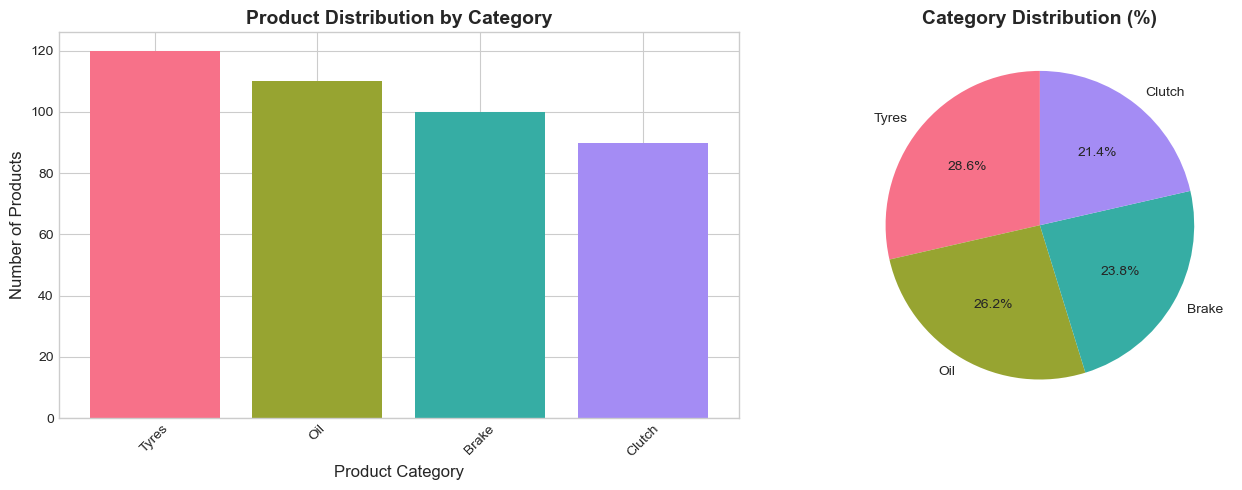


Categories present: ['Brake', 'Oil', 'Tyres', 'Clutch']


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

category_counts = df['Product Category'].value_counts()
colors = sns.color_palette('husl', len(category_counts))

axes[0].bar(category_counts.index, category_counts.values, color=colors)
axes[0].set_xlabel('Product Category', fontsize=12)
axes[0].set_ylabel('Number of Products', fontsize=12)
axes[0].set_title('Product Distribution by Category', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('Category Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCategories present:", df['Product Category'].unique().tolist())


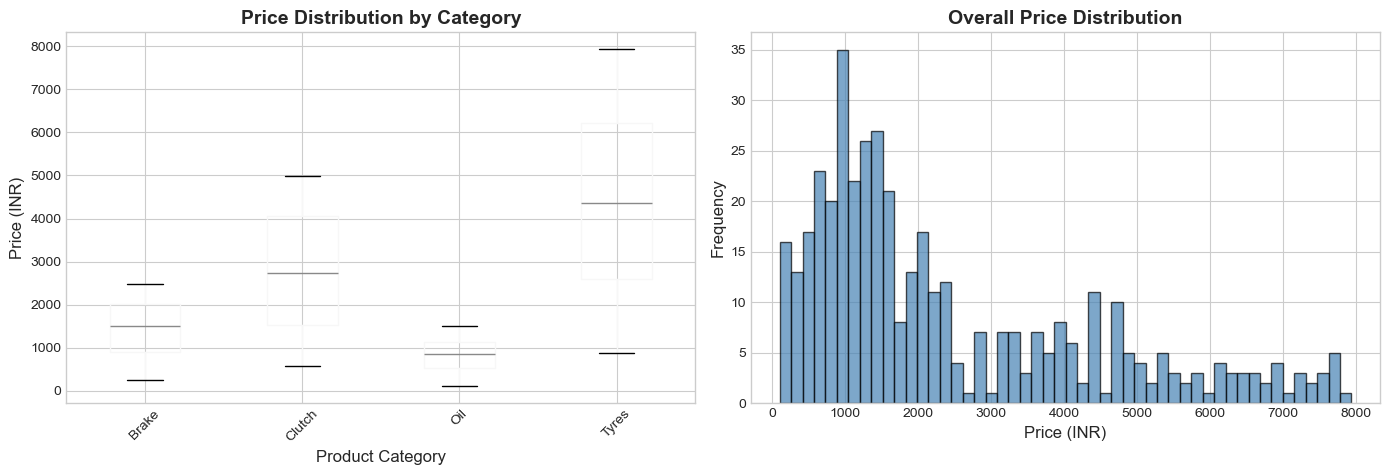

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.boxplot(column='Price', by='Product Category', ax=axes[0])
axes[0].set_xlabel('Product Category', fontsize=12)
axes[0].set_ylabel('Price (INR)', fontsize=12)
axes[0].set_title('Price Distribution by Category', fontsize=14, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
plt.suptitle('')

axes[1].hist(df['Price'], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Price (INR)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)
axes[1].set_title('Overall Price Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


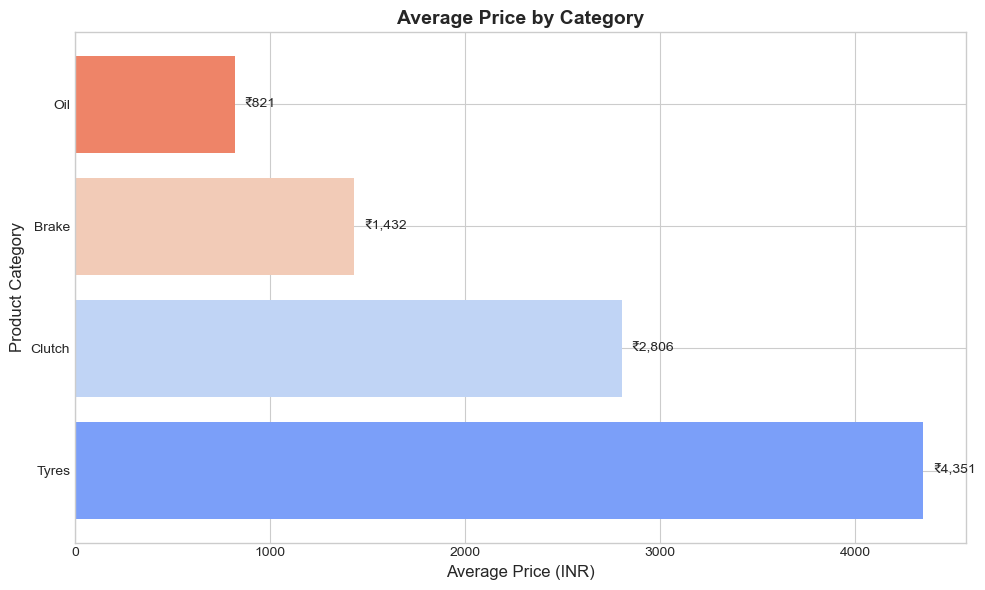

In [17]:
avg_price = df.groupby('Product Category')['Price'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
colors = sns.color_palette('coolwarm', len(avg_price))
bars   = plt.barh(avg_price.index, avg_price.values, color=colors)
plt.xlabel('Average Price (INR)', fontsize=12)
plt.ylabel('Product Category', fontsize=12)
plt.title('Average Price by Category', fontsize=14, fontweight='bold')

for bar, val in zip(bars, avg_price.values):
    plt.text(val + 50, bar.get_y() + bar.get_height()/2,
             f'\u20b9{val:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


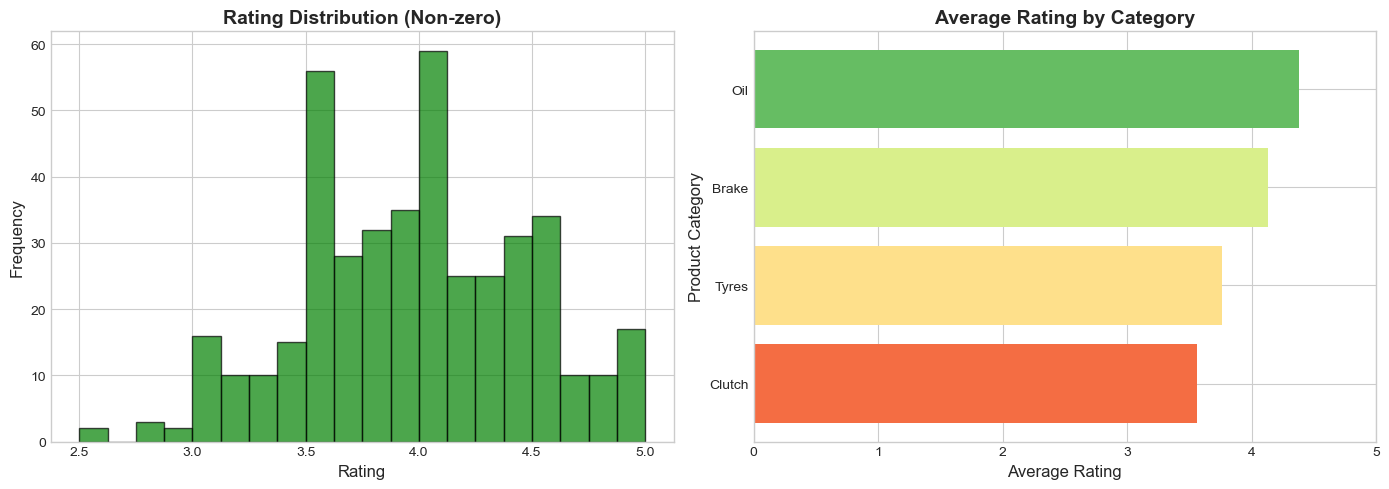

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['Rating'] > 0]['Rating'], bins=20, edgecolor='black',
             alpha=0.7, color='green')
axes[0].set_xlabel('Rating', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Rating Distribution (Non-zero)', fontsize=14, fontweight='bold')

avg_rating = (df[df['Rating'] > 0]
              .groupby('Product Category')['Rating']
              .mean()
              .sort_values(ascending=True))
colors = sns.color_palette('RdYlGn', len(avg_rating))
axes[1].barh(avg_rating.index, avg_rating.values, color=colors)
axes[1].set_xlabel('Average Rating', fontsize=12)
axes[1].set_ylabel('Product Category', fontsize=12)
axes[1].set_title('Average Rating by Category', fontsize=14, fontweight='bold')
axes[1].set_xlim(0, 5)

plt.tight_layout()
plt.show()


In [19]:
review_stats = df.groupby('Product Category')['Review'].agg(['sum','mean']).round(0)
review_stats.columns = ['Total Reviews', 'Avg Reviews']
review_stats = review_stats.sort_values('Total Reviews', ascending=False)
print("Review Statistics by Category:")
print(review_stats)


Review Statistics by Category:
                  Total Reviews  Avg Reviews
Product Category                            
Oil                       67823        617.0
Tyres                     55147        460.0
Brake                     29893        299.0
Clutch                    25317        281.0


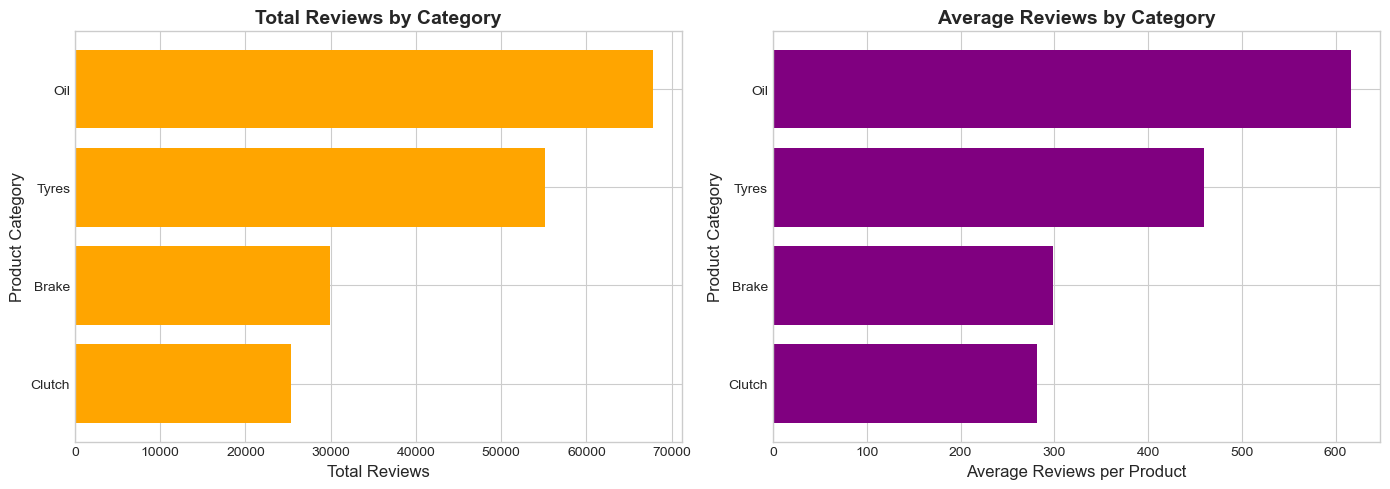

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

total_reviews = df.groupby('Product Category')['Review'].sum().sort_values(ascending=True)
axes[0].barh(total_reviews.index, total_reviews.values, color='orange')
axes[0].set_xlabel('Total Reviews', fontsize=12)
axes[0].set_ylabel('Product Category', fontsize=12)
axes[0].set_title('Total Reviews by Category', fontsize=14, fontweight='bold')

avg_reviews = df.groupby('Product Category')['Review'].mean().sort_values(ascending=True)
axes[1].barh(avg_reviews.index, avg_reviews.values, color='purple')
axes[1].set_xlabel('Average Reviews per Product', fontsize=12)
axes[1].set_ylabel('Product Category', fontsize=12)
axes[1].set_title('Average Reviews by Category', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


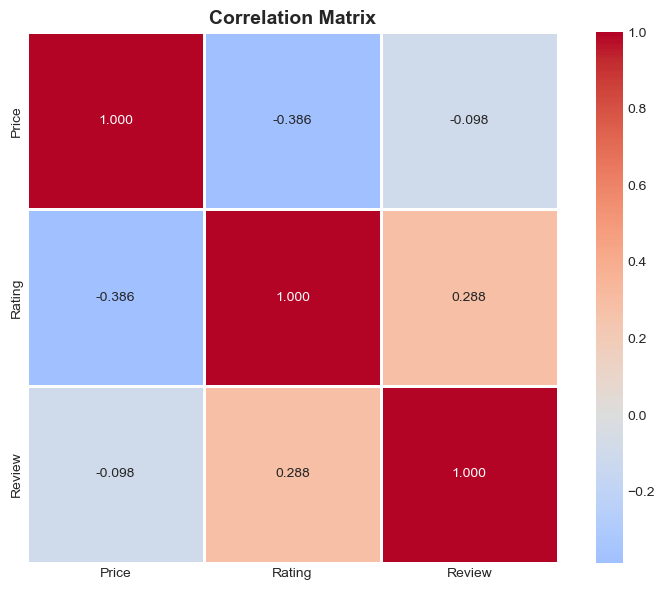

In [21]:
numeric_cols = df[['Price', 'Rating', 'Review']]
correlation  = numeric_cols.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=2, fmt='.3f')
plt.title('Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


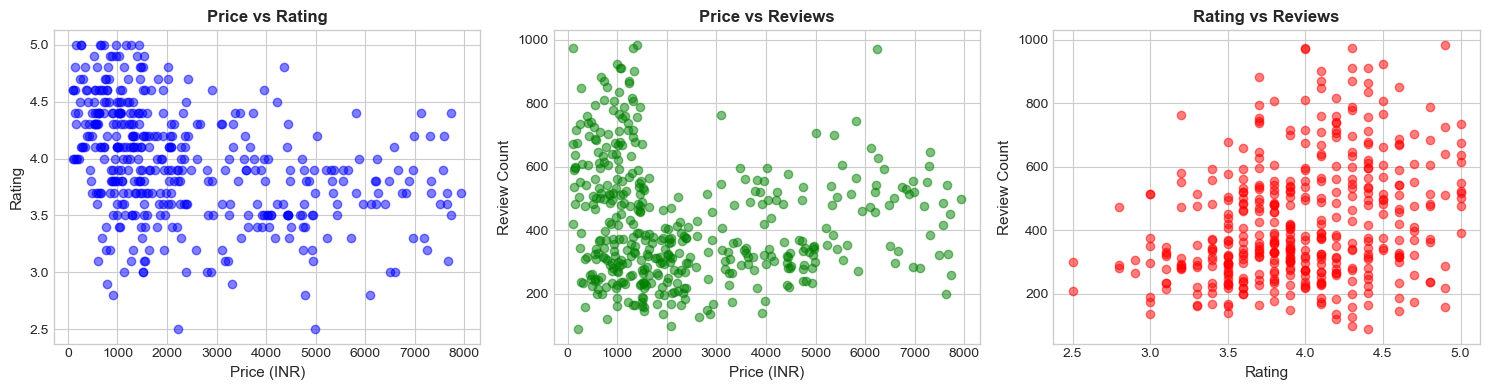

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(df['Price'], df['Rating'], alpha=0.5, c='blue')
axes[0].set_xlabel('Price (INR)', fontsize=11)
axes[0].set_ylabel('Rating', fontsize=11)
axes[0].set_title('Price vs Rating', fontsize=12, fontweight='bold')

axes[1].scatter(df['Price'], df['Review'], alpha=0.5, c='green')
axes[1].set_xlabel('Price (INR)', fontsize=11)
axes[1].set_ylabel('Review Count', fontsize=11)
axes[1].set_title('Price vs Reviews', fontsize=12, fontweight='bold')

axes[2].scatter(df['Rating'], df['Review'], alpha=0.5, c='red')
axes[2].set_xlabel('Rating', fontsize=11)
axes[2].set_ylabel('Review Count', fontsize=11)
axes[2].set_title('Rating vs Reviews', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [23]:
df.to_csv('flipkart_cleaned_data.csv', index=False)
print("Cleaned data saved to 'flipkart_cleaned_data.csv'")
print(f"\nFinal dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nCategories saved: {sorted(df['Product Category'].unique().tolist())}")


Cleaned data saved to 'flipkart_cleaned_data.csv'

Final dataset shape: (420, 5)
Columns: ['Product Name', 'Product Category', 'Price', 'Rating', 'Review']

Categories saved: ['Brake', 'Clutch', 'Oil', 'Tyres']


In [24]:
df.head(10)


,Product Name,Product Category,Price,Rating,Review
0,Brake Product 26,Brake,576,4.3,340
1,Oil Product 25,Oil,784,4.6,851
2,Brake Product 56,Brake,2014,4.8,237
3,Oil Product 60,Oil,670,3.7,883
4,Oil Product 107,Oil,374,4.6,542
5,Tyres Product 74,Tyres,7118,4.4,281
6,Brake Product 13,Brake,2110,4.2,313
7,Brake Product 18,Brake,617,3.7,243
8,Tyres Product 31,Tyres,4340,3.6,483
9,Tyres Product 73,Tyres,5328,3.8,478
